# RL evaluation (PPO / SAC + SB3)

Closed-loop eval and learning curves for state-based RL.

Loads **PPO / SAC** (`model.pt`) and **SB3 PPO / SAC** (`sb3_*/model.zip`) checkpoints.

Summary vs imitation: [`notebooks/compare.ipynb`](../compare.ipynb).


# Setup

In [ ]:
!pip install -q mujoco gymnasium numpy imageio imageio-ffmpeg tqdm pandas matplotlib stable-baselines3

In [ ]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    repo = Path("/content/drive/MyDrive/visual-policy-learning")
except ImportError:
    here = Path.cwd().resolve()
    repo = next((p for p in [here, *here.parents] if (p / "pyproject.toml").exists()), here)

os.chdir(repo)
if Path("/content").exists():
    os.environ.setdefault("MUJOCO_GL", "egl")
print("cwd:", os.getcwd())

import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


os.makedirs("results/metrics/rl", exist_ok=True)
print("cwd:", os.path.basename(os.getcwd()))


# Evaluate seeded checkpoints

In [1]:
from envs.panda_reach_state_env import PandaReachStateEnv
from policies.load_policy import load_rl_policy
from evals.eval_utils import evaluate_rl_policy, rollout_rl_episode
import glob, os, json

NUM_EPISODES = 25
MAX_STEPS = 200

# Evaluate PPO/SAC and SB3 runs side by side
RUNS = [
    # (algo, run_name, backend)
    ("ppo", "ppo", "scratch"),
    ("sac", "sac", "scratch"),
    ("ppo", "sb3_ppo", "sb3"),
    ("sac", "sb3_sac", "sb3"),
]


def make_env(sparse_reward=False):
    return PandaReachStateEnv(
        render_mode=False,
        max_steps=MAX_STEPS,
        physics_steps=4,
        sparse_reward=sparse_reward,
    )


def eval_run(algo, run_name, backend, sparse_reward=False):
    """Eval every seed under models/rl/checkpoints/{run_name}/seed_*/"""
    results = {}
    seed_dirs = sorted(glob.glob(f"models/rl/checkpoints/{run_name}/seed_*"))
    if not seed_dirs:
        print(f"(skip {run_name}: no checkpoints)")
        return results

    for seed_dir in seed_dirs:
        stem = os.path.join(seed_dir, "model")
        if backend == "scratch" and not os.path.exists(stem + ".pt"):
            print("missing", stem + ".pt")
            continue
        if backend == "sb3" and not os.path.exists(stem + ".zip"):
            print("missing", stem + ".zip")
            continue

        seed = os.path.basename(seed_dir)
        name = f"{run_name}/{seed}"
        policy = load_rl_policy(
            algo, stem, backend=backend, make_env_fn=make_env, device="cpu"
        )

        metrics = evaluate_rl_policy(
            env_fn=lambda sr=sparse_reward: make_env(sparse_reward=sr),
            policy=policy,
            num_episodes=NUM_EPISODES,
            max_steps=MAX_STEPS,
        )

        out = f"results/metrics/rl/{run_name}_{seed}_eval.json"
        with open(out, "w") as f:
            json.dump(
                {
                    "algo": algo,
                    "backend": backend,
                    "run_name": run_name,
                    "seed": seed,
                    **metrics,
                    "checkpoint": stem,
                },
                f,
                indent=4,
            )

        results[name] = metrics
        print(name, metrics)

    return results


all_results = {}
for algo, run_name, backend in RUNS:
    all_results.update(eval_run(algo, run_name, backend))



cwd: visual-policy-learning
ppo/seed_42 {'success_rate': 0.96, 'avg_reward': -13.066318851267907, 'avg_steps': 50.0, 'reward_std': 9.984205668334985, 'num_episodes': 25}
sac/seed_42 {'success_rate': 1.0, 'avg_reward': -9.22702040385014, 'avg_steps': 42.6, 'reward_std': 2.03093521419524, 'num_episodes': 25}
sb3_ppo/seed_42 {'success_rate': 1.0, 'avg_reward': -8.566869582693633, 'avg_steps': 35.92, 'reward_std': 1.9268135255834677, 'num_episodes': 25}
sb3_sac/seed_42 {'success_rate': 0.96, 'avg_reward': -11.582228107105731, 'avg_steps': 42.68, 'reward_std': 15.383490959790118, 'num_episodes': 25}


# PPO / SAC vs SB3 summary

Aggregates whatever checkpoints were found above.


In [1]:
def summarize(result_dict):
    if not result_dict:
        return None
    srs = [m["success_rate"] for m in result_dict.values()]
    rews = [m["avg_reward"] for m in result_dict.values()]
    steps = [m["avg_steps"] for m in result_dict.values()]
    return {
        "success_rate_mean": float(np.mean(srs)),
        "success_rate_std": float(np.std(srs)),
        "avg_reward_mean": float(np.mean(rews)),
        "avg_reward_std": float(np.std(rews)),
        "avg_steps_mean": float(np.mean(steps)),
        "num_seeds": len(result_dict),
    }


def group_results(all_results):
    """Group by run name: ppo / sac / sb3_ppo / sb3_sac."""
    groups = {}
    for name, metrics in all_results.items():
        # name like ppo/seed_42 or sb3_ppo/seed_42
        run_name = name.split("/")[0]
        groups.setdefault(run_name, {})[name] = metrics
    return {k: summarize(v) for k, v in groups.items()}


rl_comparison = group_results(all_results)

# Keep a short top-level alias for the default (non-SB3) runs
out = {
    "protocol": {
        "ppo_timesteps": 150000,
        "sac_timesteps": 50000,
        "eval_episodes": NUM_EPISODES,
        "note": "PPO/SAC and SB3 under the same budgets.",
    },
    "grouped": rl_comparison,
    "runs": all_results,
    "ppo": {**rl_comparison.get("ppo", {}), "total_timesteps": 150000},
    "sac": {**rl_comparison.get("sac", {}), "total_timesteps": 50000},
}
with open("results/metrics/rl/ppo_vs_sac.json", "w") as f:
    json.dump(out, f, indent=4)

print(json.dumps(out["grouped"], indent=2))



{
  "ppo": {
    "success_rate_mean": 0.96,
    "success_rate_std": 0.0,
    "avg_reward_mean": -13.066318851267907,
    "avg_reward_std": 0.0,
    "avg_steps_mean": 50.0,
    "num_seeds": 1
  },
  "sac": {
    "success_rate_mean": 1.0,
    "success_rate_std": 0.0,
    "avg_reward_mean": -9.22702040385014,
    "avg_reward_std": 0.0,
    "avg_steps_mean": 42.6,
    "num_seeds": 1
  },
  "sb3_ppo": {
    "success_rate_mean": 1.0,
    "success_rate_std": 0.0,
    "avg_reward_mean": -8.566869582693633,
    "avg_reward_std": 0.0,
    "avg_steps_mean": 35.92,
    "num_seeds": 1
  },
  "sb3_sac": {
    "success_rate_mean": 0.96,
    "success_rate_std": 0.0,
    "avg_reward_mean": -11.582228107105731,
    "avg_reward_std": 0.0,
    "avg_steps_mean": 42.68,
    "num_seeds": 1
  }
}


# Learning curves (PPO / SAC solid, SB3 dashed)


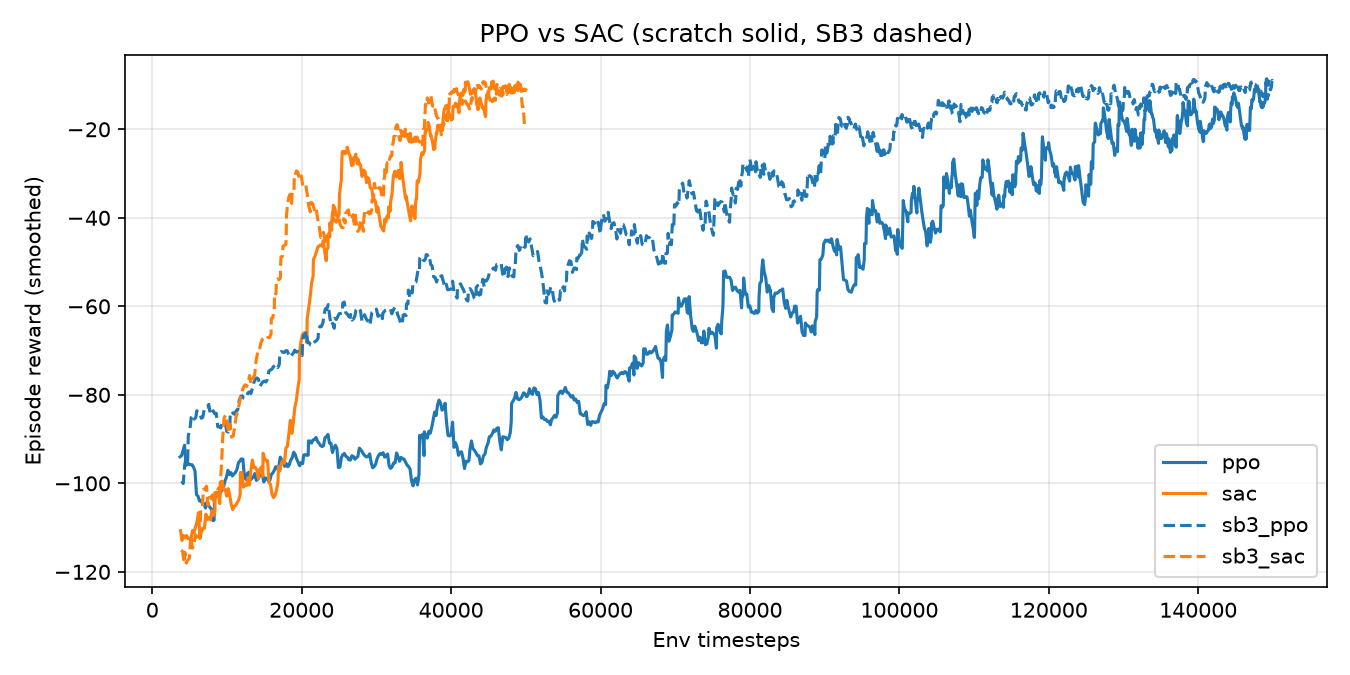

In [1]:
def load_curves(run_name, smooth=20):
    paths = sorted(
        glob.glob(f"models/rl/checkpoints/{run_name}/seed_*/learning_curve.csv")
    )
    series = []
    for path in paths:
        df = pd.read_csv(path)
        if len(df) == 0:
            continue
        reward = df["episode_reward"].to_numpy()
        steps = df["timesteps"].to_numpy()
        if smooth > 1 and len(reward) >= smooth:
            kernel = np.ones(smooth) / smooth
            reward = np.convolve(reward, kernel, mode="valid")
            steps = steps[smooth - 1 :]
        series.append((steps, reward))
    return series


plt.figure(figsize=(9, 4.5))
for run_name, color, ls in [
    ("ppo", "C0", "-"),
    ("sac", "C1", "-"),
    ("sb3_ppo", "C0", "--"),
    ("sb3_sac", "C1", "--"),
]:
    series = load_curves(run_name)
    if not series:
        print("no curves for", run_name)
        continue
    label = run_name
    if len(series) == 1:
        plt.plot(series[0][0], series[0][1], label=label, color=color, linestyle=ls)
    else:
        min_len = min(len(s[1]) for s in series)
        steps = series[0][0][:min_len]
        stack = np.stack([s[1][:min_len] for s in series], axis=0)
        mean, std = stack.mean(0), stack.std(0)
        plt.plot(steps, mean, label=label, color=color, linestyle=ls)
        plt.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

plt.xlabel("Env timesteps")
plt.ylabel("Episode reward (smoothed)")
plt.title("PPO vs SAC (solid = ours, dashed = SB3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/metrics/rl/learning_curves.png", dpi=150)
plt.show()



# Rollout videos

Writes `videos/ppo_demo.mp4` and `videos/sac_demo.mp4`.


In [1]:
os.makedirs("videos", exist_ok=True)

def make_render_env():
    return PandaReachStateEnv(
        render_mode=True,
        image_width=480,
        image_height=480,
        max_steps=MAX_STEPS,
        physics_steps=4,
    )

# Prefer PPO/SAC demos; fall back to SB3 if needed
for algo, run, backend, video in [
    ("ppo", "ppo", "scratch", "videos/ppo_demo.mp4"),
    ("sac", "sac", "scratch", "videos/sac_demo.mp4"),
]:
    stem = f"models/rl/checkpoints/{run}/seed_42/model"
    need = stem + (".pt" if backend == "scratch" else ".zip")
    if not os.path.exists(need):
        run, backend = f"sb3_{algo}", "sb3"
        stem = f"models/rl/checkpoints/{run}/seed_42/model"
        need = stem + ".zip"
    if not os.path.exists(need):
        print("skip demo; missing", need)
        continue
    policy = load_rl_policy(algo, stem, backend=backend, make_env_fn=make_env, device="cpu")
    env = make_render_env()
    rollout_rl_episode(env, policy, max_steps=MAX_STEPS, save_video=True, video_path=video)
    env.close()
    print("saved", video)



saved videos/ppo_demo.mp4
saved videos/sac_demo.mp4
